In [6]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
import Modeling
importlib.reload(Modeling)
from Modeling.models.plotting import animate_field_1d
from Modeling.models.beam_properties import PiezoBeamParams
from Modeling.models import FE_helpers 
importlib.reload(FE_helpers)
import matplotlib.pyplot as plt
# from Modeling.models.ROM import ROM

import Modeling.models.FE3 as FE_module
importlib.reload(FE_module)
import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from datetime import datetime
import pickle
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import pickle
import shutil

from pathlib import Path
from datetime import datetime
from collections import defaultdict
from joblib import Parallel, delayed
# =========================================================
# Sweep configuration
# =========================================================
SAVE_PREFIX = "Alternating_Kc_"  # Leading filename for all outputs
params_fe = PiezoBeamParams(
                            hp=0.252e-3, hs=0.51e-3,
                            # hp=0.31e-3, hs=0.607e-3,
                            d31= -1.48e-10,eps_r=1700,
							# rho_p=8000,
							# omega_p=2*pi*100, omega_q=2*pi*1000
                            )
params_fe.zeta_p = 0.0151*8
params_fe.zeta_q = 0.0392*10
K_p = 0.032
interface_idx = 10
beta = 0

ki0 = 2000
ki1 = ki0 / (1 - beta)**2 
ki2 = ki0 / (1 + beta)**2 

K_i = np.array([ki1, ki2] * (interface_idx // 2)
               + [ki2, ki1] * (15 - interface_idx // 2)
               + [ki2])

R_c = 1e3

t_end = 0.01
f0 = 1000
f1 = 3000
dt = 1 / f1 / 50

amp_list = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]) * 125

kc_magnitudes = [1e10, 2e10]
Kc_cases = [
	{
		"label": f"Kc_{i}",
		"kc_vec": np.array(
			[kc, kc] * (interface_idx // 2)
			+ [kc, kc] * (15 - interface_idx // 2)
		)
	}
	for i, kc in enumerate(kc_magnitudes)
]

# =========================================================
# STUDY-LEVEL OUTPUT SPECIFICATION
# =========================================================
OUTPUT_SPEC = {
	"freq": lambda out: out["spectral"]["freq"],
	"X":  lambda out: out["spectral"]["X"],
	"Y":  lambda out: out["spectral"]["Y"],
	"u_dot":  lambda out: out["spectral"]["FRF"],
	# "voltage": lambda out: out["spectral"]["v"],

}


sim_dat_dir = Path.cwd() / "sim_dat"
sim_dat_dir.mkdir(parents=True, exist_ok=True)


def unique_path(path: Path) -> Path:
	if not path.exists():
		return path
	counter = 1
	while True:
		candidate = path.with_name(f"{path.stem}_{counter}{path.suffix}")
		if not candidate.exists():
			return candidate
		counter += 1


def unique_dir(path: Path) -> Path:
	if not path.exists():
		path.mkdir(parents=True, exist_ok=False)
		return path
	counter = 1
	while True:
		candidate = path.with_name(f"{path.name}_{counter}")
		if not candidate.exists():
			candidate.mkdir(parents=True, exist_ok=False)
			return candidate
		counter += 1


run_dir = unique_dir(sim_dat_dir / SAVE_PREFIX)
intermediate_dir = run_dir / "intermediate_npz"
intermediate_dir.mkdir(parents=True, exist_ok=True)

png_path = run_dir / f"{SAVE_PREFIX}.png"
pickle_path = run_dir / f"{SAVE_PREFIX}.pkl"
err_path = run_dir / f"{SAVE_PREFIX}_errors.json"
print(f"Run output folder: {run_dir}")

# =========================================================
# Simulation kernel (PURE, MEMORY-SAFE)
# =========================================================
def run_single_simulation(
	amp, kc, kc_label,
	K_p, K_i, R_c,
	fe_params,
	dt, t_end, f0, f1,
	output_spec
):
	try:
		fe = FE_module.PiezoBeamFE(fe_params)

		def v_exc(t):
			return amp * np.sin(
				2 * np.pi * (f0 + t * (f1 - f0) / t_end) * t
			)

		ode = fe.build_ode_system(
			j_exc=30,
			K_c=kc,
			K_i=K_i,
			K_p=K_p,
			R_c=R_c,
			v_exc=v_exc
		)

		out =  FE_helpers.solve_newmark(
			ode=ode,
			dt=dt,
			t_end=t_end,
			beta=0.25,
			gamma=0.5,
			newton_tol=1e-8,
			newton_maxiter=8,
			x0=np.zeros(ode.M.shape[0]),
			x_dot0=np.zeros(ode.M.shape[0]),
			do_spectral=True
		)

		saved_data = {
			"amp": amp,
			"kc_label": kc_label,
			"kc_vec": kc
		}

		for name, extractor in output_spec.items():
			saved_data[name] = extractor(out)

		fname = f"amp_{amp:.3f}_{kc_label}.npz"
		np.savez_compressed(intermediate_dir / fname, **saved_data)

		return dict(
			ok=True,
			amp=amp,
			kc_label=kc_label,
			file=fname
		)

	except Exception as e:
		return dict(
			ok=False,
			amp=amp,
			kc_label=kc_label,
			error=str(e),
			exception=type(e).__name__
		)

# =========================================================
# Build sweep grid
# =========================================================
sweep = [
	{
		"amp": amp,
		"kc_label": case["label"],
		"kc_vec": case["kc_vec"]
	}
	for amp in amp_list
	for case in Kc_cases
]

print(f"Total simulations: {len(sweep)}")
print("Running sweep in parallel...\n")

# =========================================================
# Run sweep
# =========================================================
results = Parallel(n_jobs=7, verbose=10)(
	delayed(run_single_simulation)(
		s["amp"],
		s["kc_vec"],
		s["kc_label"],
		K_p, K_i, R_c,
		params_fe,
		dt, t_end, f0, f1,
		OUTPUT_SPEC
	)
	for s in sweep
)

# =========================================================
# Separate success / failure
# =========================================================
successful = [r for r in results if r["ok"]]
failed     = [r for r in results if not r["ok"]]

print(f"Successful: {len(successful)}")
print(f"Failed:     {len(failed)}\n")

# =========================================================
# Load intermediate NPZ files
# =========================================================
results_by_kc = defaultdict(lambda: {
	"kc_label": None,
	"kc_vec": None,
	"amps": [],
	"data": defaultdict(list)
})

for r in successful:
	data = np.load(intermediate_dir / r["file"], allow_pickle=True)

	label = data["kc_label"].item()
	block = results_by_kc[label]

	block["kc_label"] = label
	block["kc_vec"] = data["kc_vec"]
	block["amps"].append(float(data["amp"]))

	for key in OUTPUT_SPEC:
		block["data"][key].append(data[key])

# =========================================================
# Plotting
# =========================================================
kc_labels_sorted = [case["label"] for case in Kc_cases]

fig, axes = plt.subplots(
	len(kc_labels_sorted), 1,
	figsize=(10, 4 * len(kc_labels_sorted)),
	sharex=True
)

if len(kc_labels_sorted) == 1:
	axes = [axes]

for ax, key in zip(axes, kc_labels_sorted):
	block = results_by_kc[key]
	cmap = plt.cm.viridis
	colors = cmap(np.linspace(0, 1, len(block["amps"])))

	for amp, freq, FRF, col in zip(
		block["amps"],
		block["data"]["freq"],
		block["data"]["FRF"],
		colors
	):
		ax.semilogy(freq, FRF, color=col, label=f"A = {amp:.1f} V")

	ax.set_xlim([1300, 3000])
	ax.set_ylim([3e-5, 6e-4])
	ax.set_title(f"K_c case: {key}")
	ax.set_ylabel("FRF magnitude")
	ax.grid(True)
	ax.legend(fontsize=8)

axes[-1].set_xlabel("Frequency [Hz]")
plt.tight_layout()
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.close(fig)

# =========================================================
# Save final aggregated pickle
# =========================================================
save_dict = {
	"amp_list": amp_list,
	"K_p": K_p,
	"K_i": K_i,
	"R_c": R_c,
	"dt": dt,
	"f0": f0,
	"f1": f1,
	"t_end": t_end,
	"output_spec_keys": list(OUTPUT_SPEC.keys()),
	"results_by_kc": dict(results_by_kc),
	"failed": failed,
	"run_dir": str(run_dir)
}

with open(pickle_path, "wb") as f:
	pickle.dump(save_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

config_dict = {
	"amp_list": amp_list.tolist(),
	"kc_magnitudes": kc_magnitudes,
	"Kc_cases": [
		{"label": case["label"], "kc_vec": case["kc_vec"].tolist()}
		for case in Kc_cases
	],
	"K_p": float(K_p),
	"K_i": K_i.tolist(),
	"R_c": float(R_c),
	"dt": float(dt),
	"f0": float(f0),
	"f1": float(f1),
	"t_end": float(t_end),
	"interface_idx": int(interface_idx),
	"beta": float(beta),
	"output_spec_keys": list(OUTPUT_SPEC.keys()),
	"run_dir": str(run_dir)
}

config_path = unique_path(pickle_path.with_suffix(".json"))
with open(config_path, "w") as f:
	json.dump(config_dict, f, indent=2)

with open(err_path, "w") as f:
	json.dump({"failed": failed, "n_failed": len(failed), "n_success": len(successful)}, f, indent=2)

print(f"Saved data: {pickle_path}")
print(f"Saved config: {config_path}")
print(f"Saved errors: {err_path}")
print(f"Intermediate data kept in: {intermediate_dir}")

Run output folder: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\Alternating_Kc__3
Total simulations: 14
Running sweep in parallel...



[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   3 out of  14 | elapsed:   16.0s remaining:   59.0s
[Parallel(n_jobs=7)]: Done   5 out of  14 | elapsed:   16.3s remaining:   29.4s
[Parallel(n_jobs=7)]: Done   7 out of  14 | elapsed:   16.4s remaining:   16.4s
[Parallel(n_jobs=7)]: Done   9 out of  14 | elapsed:   31.9s remaining:   17.7s
[Parallel(n_jobs=7)]: Done  11 out of  14 | elapsed:   32.3s remaining:    8.7s
[Parallel(n_jobs=7)]: Done  14 out of  14 | elapsed:   32.6s finished


Successful: 14
Failed:     0



C:\Users\setemadi3\AppData\Local\Temp\ipykernel_13080\2221531249.py:303: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


Saved data: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\Alternating_Kc__3\Alternating_Kc_.pkl
Saved config: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\Alternating_Kc__3\Alternating_Kc_.json
Saved errors: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\Alternating_Kc__3\Alternating_Kc__errors.json
Intermediate data kept in: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\Alternating_Kc__3\intermediate_npz


Loading:
  c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\Alternating_Kc__3\Alternating_Kc_.pkl
Kc cases loaded: 2
Failed simulations: 0


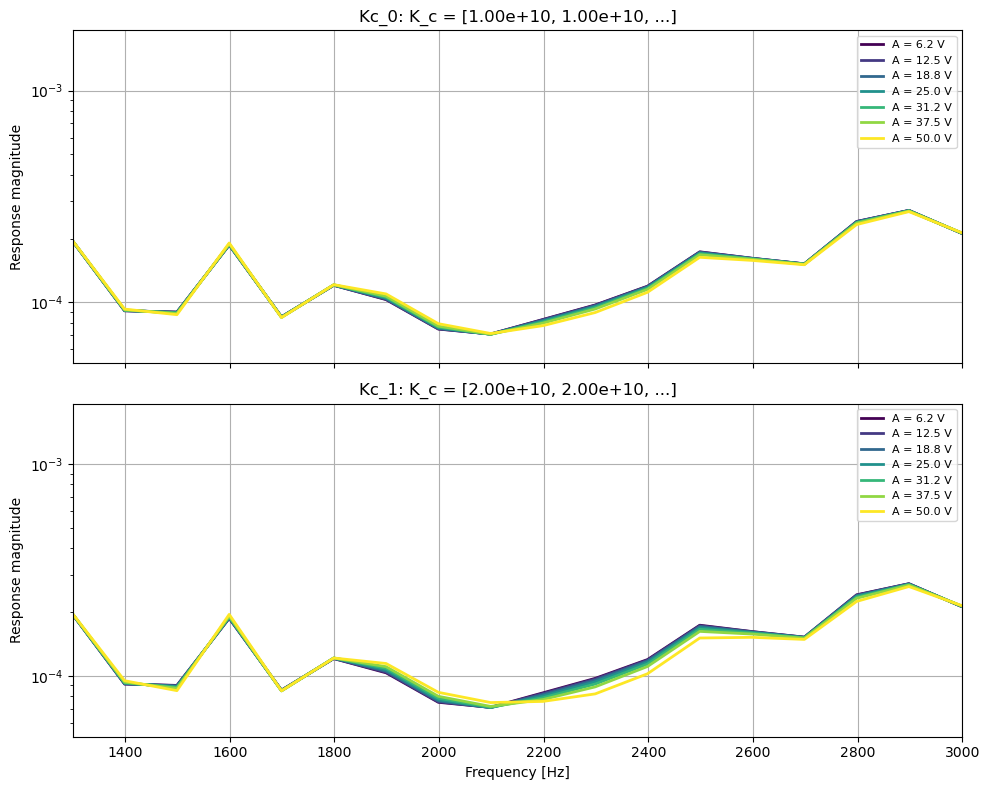

Plot saved to:
  c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\Alternating_Kc__3\loaded_data_plot.png


In [8]:
"""
Load FE sweep results from a chosen run folder and plot FRFs.
Saves the plot in the same folder.
"""

import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# User input: run folder name (under sim_dat) OR absolute path
# =========================================================
RUN_FOLDER = "Alternating_Kc__3"   # e.g. "Alternating_Kc_2"

sim_dat_dir = Path.cwd() / "sim_dat"
run_dir = Path(RUN_FOLDER)
if not run_dir.is_absolute():
	run_dir = sim_dat_dir / RUN_FOLDER

if not run_dir.exists() or not run_dir.is_dir():
	raise FileNotFoundError(f"Run folder not found: {run_dir}")

# =========================================================
# Load pickle file from selected folder
# =========================================================
pickle_candidates = sorted(run_dir.glob("*.pkl"))
if not pickle_candidates:
	raise FileNotFoundError(f"No .pkl file found in: {run_dir}")
pickle_file = pickle_candidates[-1]

print(f"Loading:\n  {pickle_file}")

with open(pickle_file, "rb") as f:
	data = pickle.load(f)

results_by_kc = data["results_by_kc"]
failed = data.get("failed", [])

print(f"Kc cases loaded: {len(results_by_kc)}")
print(f"Failed simulations: {len(failed)}")

# =========================================================
# Recover Kc label order
# =========================================================
if "Kc_labels" in data:
	kc_labels_sorted = data["Kc_labels"]
else:
	kc_labels_sorted = sorted(
		results_by_kc.keys(),
		key=lambda lbl: abs(results_by_kc[lbl]["kc_vec"][0])
	)

# =========================================================
# Helpers (robust against uneven list lengths)
# =========================================================
def get_entry(data_block, key, idx):
	if key not in data_block:
		return None
	if idx >= len(data_block[key]):
		return None
	return data_block[key][idx]


def build_curve(data_block, idx):
	frf_entry = get_entry(data_block, "FRF", idx)
	if frf_entry is not None:
		return np.asarray(frf_entry)

	u_dot_entry = get_entry(data_block, "u_dot", idx)
	if u_dot_entry is not None:
		u_dot_spec = np.asarray(u_dot_entry)
		if u_dot_spec.ndim == 2:
			return np.mean(np.abs(u_dot_spec), axis=1)
		return np.abs(u_dot_spec).squeeze()

	y_entry = get_entry(data_block, "Y", idx)
	if y_entry is not None:
		Y = np.asarray(y_entry)
		if Y.ndim == 2:
			return np.mean(np.abs(Y), axis=1)
		return np.abs(Y).squeeze()

	return None

# =========================================================
# Plot and save
# =========================================================
fig, axes = plt.subplots(
	len(kc_labels_sorted), 1,
	figsize=(10, 4 * len(kc_labels_sorted)),
	sharex=True
)

if len(kc_labels_sorted) == 1:
	axes = [axes]

for ax, label in zip(axes, kc_labels_sorted):
	block = results_by_kc[label]
	amps = block["amps"]
	data_block = block["data"]

	freq_list = data_block.get("freq", [])
	n_valid = min(len(amps), len(freq_list))

	cmap = plt.cm.viridis
	colors = cmap(np.linspace(0, 1, max(n_valid, 1)))

	skipped = 0
	for idx in range(n_valid):
		amp = amps[idx]
		col = colors[idx]
		freq = np.asarray(freq_list[idx])
		curve = build_curve(data_block, idx)

		if curve is None:
			skipped += 1
			continue

		curve = np.asarray(curve).squeeze()
		if freq.shape[0] != curve.shape[0]:
			n = min(freq.shape[0], curve.shape[0])
			freq = freq[:n]
			curve = curve[:n]

		ax.semilogy(freq, curve, color=col, linewidth=2, label=f"A = {amp:.1f} V")

	kc_vec = block["kc_vec"]
	ax.set_title(f"{label}: K_c = [{kc_vec[0]:.2e}, {kc_vec[1]:.2e}, ...]")
	ax.set_ylabel("Response magnitude")
	ax.grid(True)
	if n_valid - skipped > 0:
		ax.legend(fontsize=8)
	if skipped > 0:
		print(f"{label}: skipped {skipped} incomplete traces")

axes[-1].set_xlabel("Frequency [Hz]")
axes[-1].set_xlim([1300, 3000])

plt.tight_layout()
plot_path = run_dir / "loaded_data_plot.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot saved to:\n  {plot_path}")

In [4]:
kc_labels_sorted = data["Kc_labels"]

KeyError: 'Kc_labels'

Mode shape at 1799.99 Hz for Kc_3


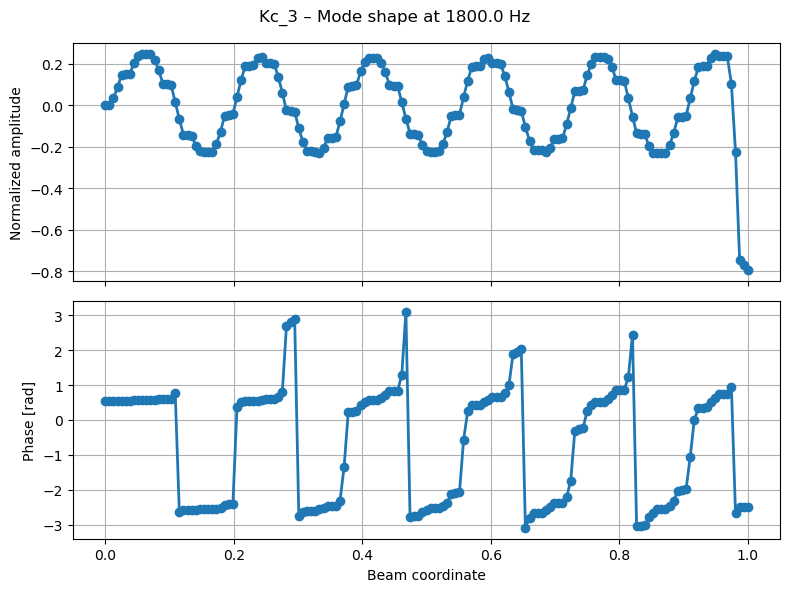

In [ ]:
label = kc_labels_sorted[-2]
block = results_by_kc[label]

amp_idx = -1
res = block["result"][amp_idx]

spec = res["spectral"]
freq = spec["freq"]
Y = spec["Y"]

f_target = 1800.0
f_idx = np.argmin(np.abs(freq - f_target))

mode_shape_vel = Y[f_idx, :]
f_found = freq[f_idx]

print(f"Mode shape at {f_found:.2f} Hz for {label}")
x = np.linspace(0, 1, mode_shape_vel.size)

phi = mode_shape_vel / np.max(np.abs(mode_shape_vel))

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axs[0].plot(x, np.real(phi), 'o-', linewidth=2)
axs[0].set_ylabel("Normalized amplitude")
axs[0].grid(True)

axs[1].plot(x, np.angle(phi), 'o-', linewidth=2)
axs[1].set_ylabel("Phase [rad]")
axs[1].set_xlabel("Beam coordinate")
axs[1].grid(True)

fig.suptitle(f"{label} – Mode shape at {f_found:.1f} Hz")
plt.tight_layout()
plt.show()



Heatmap for Kc_3, amp=18.75 V


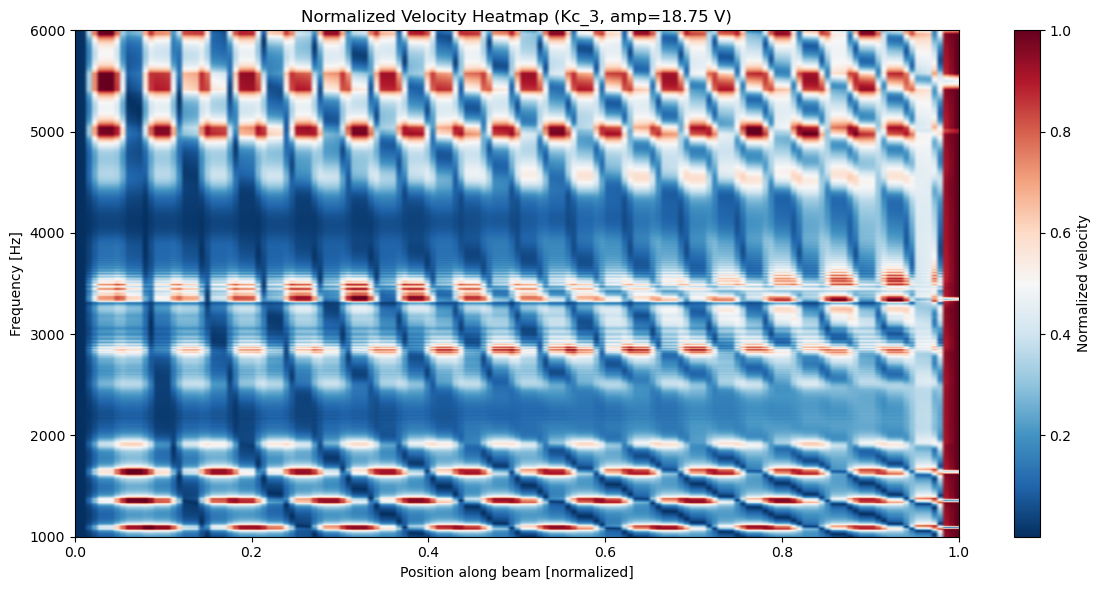

In [ ]:
# Heatmap: normalized velocity for all frequencies (from spectral Y)
# Y is FFT of velocity field with shape (n_freq, n_nodes)
label = kc_labels_sorted[-2]
block = results_by_kc[label]

amp_idx = 2
res = block["result"][amp_idx]
print(f"Heatmap for {label}, amp={block['amps'][amp_idx]:.2f} V")
spec = res["spectral"]
freq = spec["freq"]
Y = spec["Y"]

v_plot_all = np.abs(Y)  # use np.abs(Y) if you want magnitude-only

# Normalize each frequency by its own maximum
v_plot_normalized = np.zeros_like(v_plot_all, dtype=float)
for i in range(v_plot_all.shape[0]):
    max_abs_i = np.max(np.abs(v_plot_all[i, :]))
    if max_abs_i > 0:
        v_plot_normalized[i, :] = v_plot_all[i, :] / max_abs_i

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(
    v_plot_normalized,
    aspect='auto',
    origin='lower',
    cmap='RdBu_r',
    extent=[x[0], x[-1], freq[0], freq[-1]]
)
ax.set_ylim([f0, f1])
ax.set_xlabel('Position along beam [normalized]')
ax.set_ylabel('Frequency [Hz]')
ax.set_title(f'Normalized Velocity Heatmap ({label}, amp={block["amps"][amp_idx]:.2f} V)')
plt.colorbar(im, ax=ax, label='Normalized velocity')
plt.tight_layout()
plt.show()

